Dataset Shape: (51290, 27)

Data Types:
Category              str
City                  str
Country               str
Customer.ID           str
Customer.Name         str
Discount          float64
Market                str
记录数                 int64
Order.Date            str
Order.ID              str
Order.Priority        str
Product.ID            str
Product.Name          str
Profit            float64
Quantity            int64
Region                str
Row.ID              int64
Sales               int64
Segment               str
Ship.Date             str
Ship.Mode             str
Shipping.Cost     float64
State                 str
Sub.Category          str
Year                int64
Market2               str
weeknum             int64
dtype: object

Missing Values:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product

C:\Users\faaiq\AppData\Local\Temp\ipykernel_8052\950659395.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


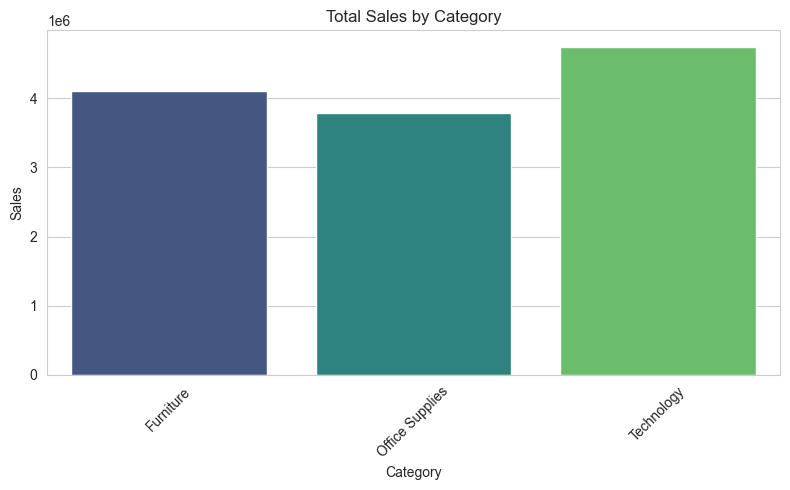

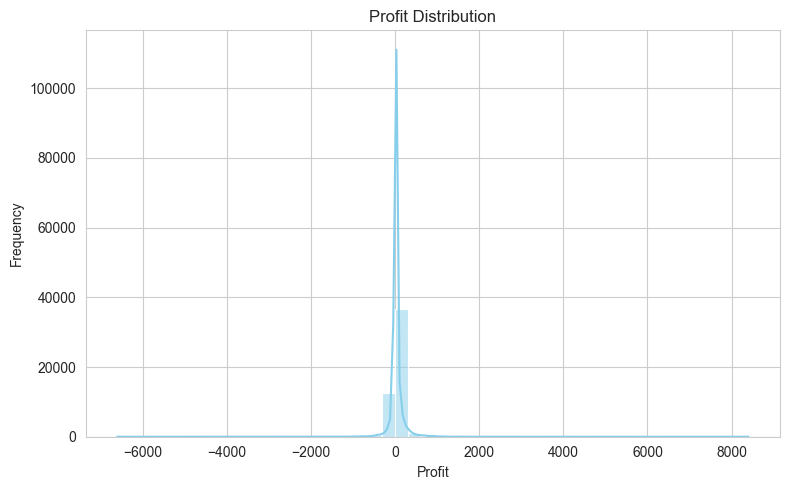

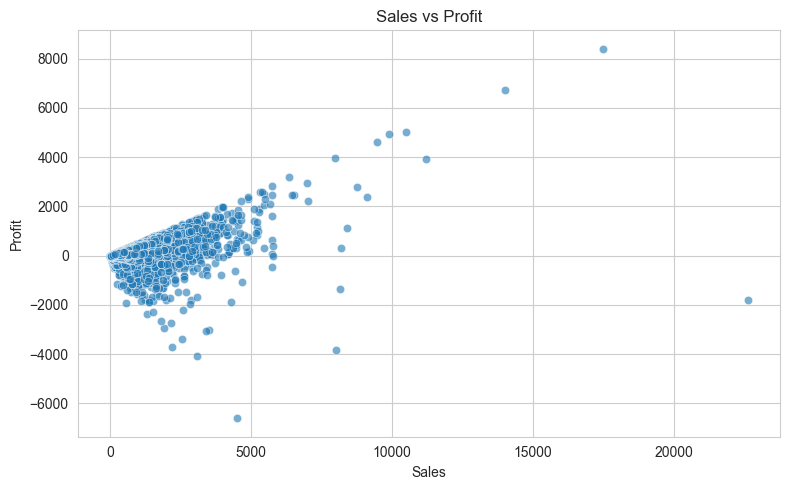

Cleaned dataset exported successfully!


In [13]:
# ==========================================================
# Superstore Sales Data Analysis
# Author: Your Name
# Purpose: Perform data cleaning, exploration, and visualization
# ==========================================================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------------

# Read the CSV file into a DataFrame
df = pd.read_csv(
    "D:/internship as data analyst/Qwetrum Technologies/Week 1/Superstore Sales Dataset/superstore.csv"
)

# ----------------------------------------------------------
# 2. Basic Data Exploration
# ----------------------------------------------------------

# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Check data types of all columns
print("\nData Types:")
print(df.dtypes)

# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# Dataset summary information
print("\nDataset Information:")
df.info()

# Statistical summary of numerical columns
print("\nSummary Statistics:")
print(df.describe())

# ----------------------------------------------------------
# 3. Data Cleaning
# ----------------------------------------------------------

# Convert date columns to datetime format
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

# Verify conversion
print("\nDate Columns Data Types:")
print(df[['Order.Date', 'Ship.Date']].dtypes)

# Remove unnecessary column
df.drop('记录数', axis=1, inplace=True)

# ----------------------------------------------------------
# 4. Feature Engineering
# ----------------------------------------------------------

# Create additional date-related features

# Month number (1-12)
df['Month'] = df['Order.Date'].dt.month

# Month name (January, February, etc.)
df['Month_Name'] = df['Order.Date'].dt.month_name()

# Quarter (1, 2, 3, 4)
df['Quarter'] = df['Order.Date'].dt.quarter

# Day of the month
df['Day'] = df['Order.Date'].dt.day

# ----------------------------------------------------------
# 5. Sales and Profit Analysis
# ----------------------------------------------------------

# Calculate total sales
print("\nTotal Sales:", df['Sales'].sum())

# Calculate total profit
print("Total Profit:", df['Profit'].sum())

# ----------------------------------------------------------
# Category-wise Sales
# ----------------------------------------------------------

print("\nSales by Category:")
print(
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

# ----------------------------------------------------------
# Sub-Category-wise Sales
# ----------------------------------------------------------

print("\nSales by Sub-Category:")
print(
    df.groupby('Sub.Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

# ----------------------------------------------------------
# Region-wise Profit
# ----------------------------------------------------------

print("\nProfit by Region:")
print(
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

# ----------------------------------------------------------
# Top 10 Countries by Sales
# ----------------------------------------------------------

print("\nTop 10 Countries by Sales:")
print(
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# ----------------------------------------------------------
# 6. Data Visualization
# ----------------------------------------------------------

# Improve plot appearance
sns.set_style("whitegrid")

# ----------------------------------------------------------
# Category-wise Sales Bar Chart
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

category_sales = df.groupby('Category')['Sales'].sum()

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart as PNG
plt.savefig("Category_Sales.png", dpi=300, bbox_inches='tight')

plt.show()


# ----------------------------------------------------------
# Profit Distribution Histogram
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df['Profit'],
    bins=50,
    kde=True,
    color='skyblue'
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()

# Save chart as PNG
plt.savefig("Profit_Distribution.png", dpi=300, bbox_inches='tight')

plt.show()

# ----------------------------------------------------------
# Sales vs Profit Scatter Plot
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()

# Save chart as PNG
plt.savefig("Sales_vs_Profit.png", dpi=300, bbox_inches='tight')

plt.show()

df.to_csv("cleaned_superstore.csv", index=False)

print("Cleaned dataset exported successfully!")
# ----------------------------------------------------------
# End of Analysis
# ----------------------------------------------------------